In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model

In [ ]:
train_dir = "../preprocessing/train"
val_dir = "../preprocessing/validation"
test_dir = "../preprocessing/test"

os.makedirs("../Outputs", exist_ok=True)

In [3]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

for layer in base_model.layers:
    layer.trainable = False

embedding_layer = Dense(
    512,
    activation="relu",
    name="iris_embedding"
)(base_model.output)

model = Model(
    inputs=base_model.input,
    outputs=embedding_layer
)

print(model.output_shape)

(None, 512)


In [6]:
sample_image = os.path.join(
    train_dir,
    os.listdir(train_dir)[0]
)

img = load_img(
    sample_image,
    target_size=(224,224)
)

img_array = img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = preprocess_input(
    img_array
)

embedding = model.predict(img_array)

print("Embedding Shape:", embedding.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Embedding Shape: (1, 512)


In [7]:
def extract_embedding(image_path):

    img = load_img(
        image_path,
        target_size=(224,224)
    )

    img_array = img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    img_array = preprocess_input(
        img_array
    )

    embedding = model.predict(
        img_array,
        verbose=0
    )

    return embedding.flatten()

In [9]:
train_embeddings = []

train_files = [
    f for f in os.listdir(train_dir)
    if f.endswith(".jpg")
]

for file in tqdm(train_files):

    path = os.path.join(
        train_dir,
        file
    )

    embedding = extract_embedding(path)

    row = [file]

    row.extend(
        embedding.tolist()
    )

    train_embeddings.append(row)

  0%|          | 0/14446 [00:00<?, ?it/s]

100%|██████████| 14446/14446 [40:19<00:00,  5.97it/s] 


In [10]:
import os

print(os.listdir("../Outputs"))

['Notebook_01', 'Notebook_02', 'Notebook_03', 'Notebook_04', 'week4_results']


In [11]:
len(train_embeddings)

14446

In [12]:
columns = ["Image"]

for i in range(512):
    columns.append(f"F{i}")

train_df = pd.DataFrame(
    train_embeddings,
    columns=columns
)

train_df.to_csv(
    "../Outputs/Notebook_03/train_embeddings.csv",
    index=False
)

print(train_df.shape)

(14446, 513)


In [14]:
import os

print(os.path.exists("../Outputs/Notebook_03/train_embeddings.csv"))

True


In [15]:
import os

size_mb = os.path.getsize("../Outputs/Notebook_03/train_embeddings.csv")/(1024*1024)

print(f"{size_mb:.2f} MB")

82.11 MB


In [17]:
val_embeddings = []

val_files = [
    f for f in os.listdir(val_dir)
    if f.endswith(".jpg")
]

for file in tqdm(val_files):

    path = os.path.join(val_dir, file)

    embedding = extract_embedding(path)

    row = [file]
    row.extend(embedding.tolist())

    val_embeddings.append(row)

100%|██████████| 2549/2549 [08:54<00:00,  4.77it/s]


In [18]:
columns = ["Image"]

for i in range(512):
    columns.append(f"F{i}")

val_df = pd.DataFrame(
    val_embeddings,
    columns=columns
)

val_df.to_csv(
    "../Outputs/Notebook_03/validation_embeddings.csv",
    index=False
)

print(val_df.shape)

(2549, 513)


In [19]:
test_embeddings = []

test_files = [
    f for f in os.listdir(test_dir)
    if f.endswith(".jpg")
]

for file in tqdm(test_files):

    path = os.path.join(test_dir, file)

    embedding = extract_embedding(path)

    row = [file]
    row.extend(embedding.tolist())

    test_embeddings.append(row)

  0%|          | 0/3000 [00:00<?, ?it/s]

100%|██████████| 3000/3000 [11:12<00:00,  4.46it/s]


In [20]:
test_df = pd.DataFrame(
    test_embeddings,
    columns=columns
)

test_df.to_csv(
    "../Outputs/Notebook_03/test_embeddings.csv",
    index=False
)

print(test_df.shape)

(3000, 513)


In [21]:
import os

print(os.listdir("../Outputs"))

['Notebook_01', 'Notebook_02', 'Notebook_03', 'Notebook_04', 'week4_results']


In [22]:
train_df.to_csv(
    "../Outputs/Notebook_03/train_embeddings.csv",
    index=False
)

In [23]:
test_df.to_csv(
    "../Outputs/Notebook_03/test_embeddings.csv",
    index=False
)

In [24]:
val_df.to_csv(
    "../Outputs/Notebook_03/validation_embeddings.csv",
    index=False
)

In [25]:
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/resnet50_feature_extractor.keras")

binary matching ANN

In [41]:
import pandas as pd

df = pd.read_csv(
    r"..\Outputs\Notebook_03\train_embeddings.csv"
)

df["Label"] = df["Image"].str.extract(r"(S\d+)")

print(df.shape)

(14446, 514)


C:\Users\kumar\AppData\Local\Temp\ipykernel_2108\1264920941.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Label"] = df["Image"].str.extract(r"(S\d+)")


In [42]:
import numpy as np
import random

pairs = []
labels = []

persons = df["Label"].unique()

# Positive pairs
for person in persons:

    person_data = df[
        df["Label"] == person
    ]

    if len(person_data) >= 2:

        sample = person_data.sample(
            2,
            random_state=42
        )

        emb1 = sample.iloc[0, 1:513].values
        emb2 = sample.iloc[1, 1:513].values

        pairs.append(
            np.abs(emb1 - emb2)
        )

        labels.append(1)

# Negative pairs
for _ in range(len(persons)):

    p1, p2 = random.sample(
        list(persons),
        2
    )

    emb1 = df[
        df["Label"] == p1
    ].iloc[0, 1:513].values

    emb2 = df[
        df["Label"] == p2
    ].iloc[0, 1:513].values

    pairs.append(
        np.abs(emb1 - emb2)
    )

    labels.append(0)

In [43]:
X = np.array(pairs)

y = np.array(labels)

print(X.shape)
print(y.shape)

(2000, 512)
(2000,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([

    Dense(
        256,
        activation="relu",
        input_shape=(512,)
    ),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\kumar\PP-IrisAuth\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,353 (642.00 KB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
print(X.dtype)
print(X_train.dtype)

object
object


In [48]:
import numpy as np

X = np.array(pairs, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

print(X.dtype)
print(y.dtype)

float32
int32


In [50]:
print(type(pairs[0]))
print(type(pairs[0][0]))

<class 'numpy.ndarray'>
<class 'numpy.float64'>


In [51]:
print(df.iloc[0, 1:513].dtype)

object


In [52]:
emb1 = sample.iloc[0, 1:513].astype(float).values
emb2 = sample.iloc[1, 1:513].astype(float).values

In [53]:
emb1 = df[df["Label"] == p1].iloc[0, 1:513].astype(float).values
emb2 = df[df["Label"] == p2].iloc[0, 1:513].astype(float).values

In [54]:
print(X.dtype)
print(type(pairs[0]))
print(type(pairs[0][0]))

float32
<class 'numpy.ndarray'>
<class 'numpy.float64'>


In [55]:
print(y.dtype)
print(y_train.dtype)
print(X_train.shape)
print(y_train.shape)

int32
int64
(1600, 512)
(1600,)


In [56]:
import numpy as np

print(np.unique(y))

[0 1]


In [57]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

print(X_train.dtype)
print(y_train.dtype)

float32
float32


In [58]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5700 - loss: 0.6845 - val_accuracy: 0.6300 - val_loss: 0.6694
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6794 - loss: 0.5977 - val_accuracy: 0.5825 - val_loss: 0.6867
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7319 - loss: 0.5247 - val_accuracy: 0.6800 - val_loss: 0.6129
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7869 - loss: 0.4629 - val_accuracy: 0.6900 - val_loss: 0.6136
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8131 - loss: 0.4024 - val_accuracy: 0.6825 - val_loss: 0.6306
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8675 - loss: 0.3177 - val_accuracy: 0.6875 - val_loss: 0.6474
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8938 - loss: 0.2693 - val_accuracy: 0.6975 - val_loss: 0.6464
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9325 - loss: 0.1920 - val_accuracy: 0.7000 - val_loss

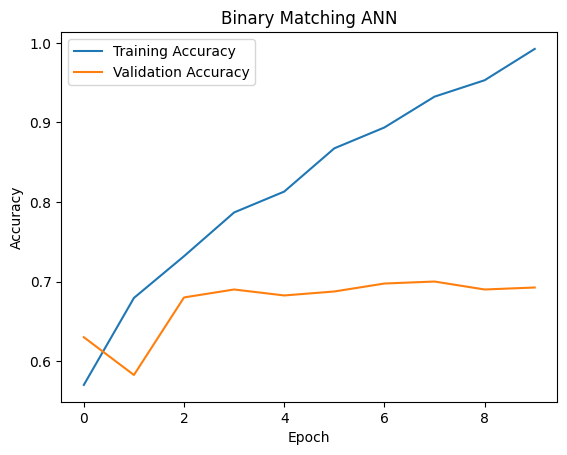

In [67]:
import matplotlib.pyplot as plt

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Binary Matching ANN")
plt.legend()
plt.savefig(
    "../Outputs/Notebook_03/37.jpg"
)

plt.show()

In [69]:
import pandas as pd

results_df = pd.DataFrame({
    "Metric": ["Training Accuracy", "Validation Accuracy"],
    "Value": [
        history.history["accuracy"][-1],
        history.history["val_accuracy"][-1]
    ]
})

results_df.to_csv(
    "../Outputs/Notebook_03/binary_matching_results.csv",
    index=False
)

print("Saved successfully")

Saved successfully
